# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import time
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

# Load Dataset

In [2]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
df = pd.read_csv(csv_url)

display(df.head())
print("\n")
df.info()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53150 entries, 0 to 53149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         53150 non-null  object 
 1   Close        53150 non-null  float64
 2   Volume USDT  53150 non-null  float64
 3   RSI          53150 non-null  float64
 4   MACD_Hist    53150 non-null  float64
 5   ATR          53150 non-null  float64
 6   KAMAO        53150 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB


## EDA

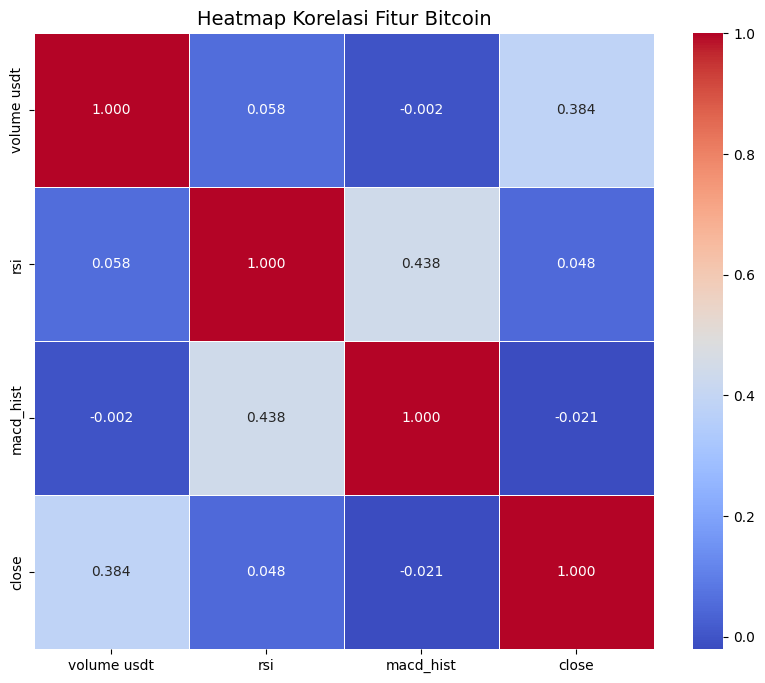

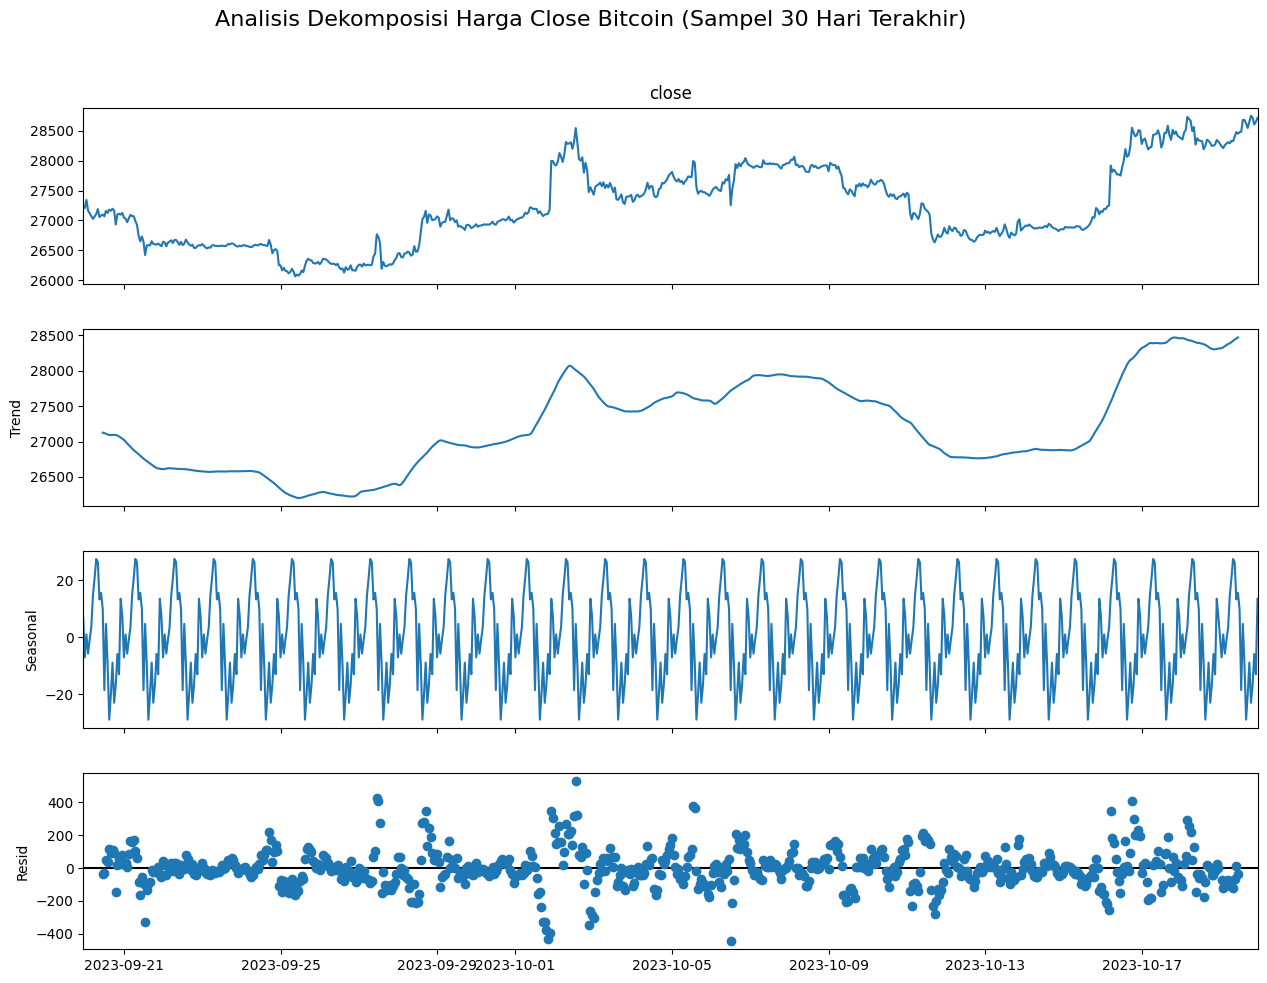

In [3]:
# 0. Merapikan nama kolom
df.columns = df.columns.str.strip().str.lower()

# 1. Preprocessing Waktu dengan penanganan format campuran
# Tambahkan format='mixed' agar Pandas bisa menangani inkonsistensi penulisan tanggal/waktu
df['date'] = pd.to_datetime(df['date'], format='mixed')
df.set_index('date', inplace=True)
df.sort_index(inplace=True) # Pastikan urutan waktu dari lampau ke masa kini

# 2. Pemilihan Fitur (Minimal 3 fitur sebagai input + target)
# Kita gunakan fitur yang tersedia: volume usdt, rsi, dan macd_hist sebagai input, serta close sebagai target
selected_features = ['volume usdt', 'rsi', 'macd_hist', 'close']
df_selected = df[selected_features]

# 3. EDA: Heatmap Korelasi antar fitur
plt.figure(figsize=(10, 8))
sns.heatmap(df_selected.corr(), annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Bitcoin', fontsize=14)
plt.show()

# 4. Analisis Dekomposisi pada Target (Close)
# Kita ambil sampel 30 hari terakhir (30 hari x 24 jam = 720 baris) agar plot tidak terlalu padat
decomposed = seasonal_decompose(df_selected['close'].tail(720), model='additive', period=24)

fig = decomposed.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Analisis Dekomposisi Harga Close Bitcoin (Sampel 30 Hari Terakhir)', fontsize=16, y=1.02)
plt.show()

## Analisis Lag, Feature Engineering, dan Preprocessing Data
- Menentukan window size menggunakan uji ACF dan PACF.
- Membuat fitur baru menggunakan Rolling Statistic.
- Membagi data menjadi Train, Validation, dan Test serta melakukan Normalisasi tanpa Data Leakage.

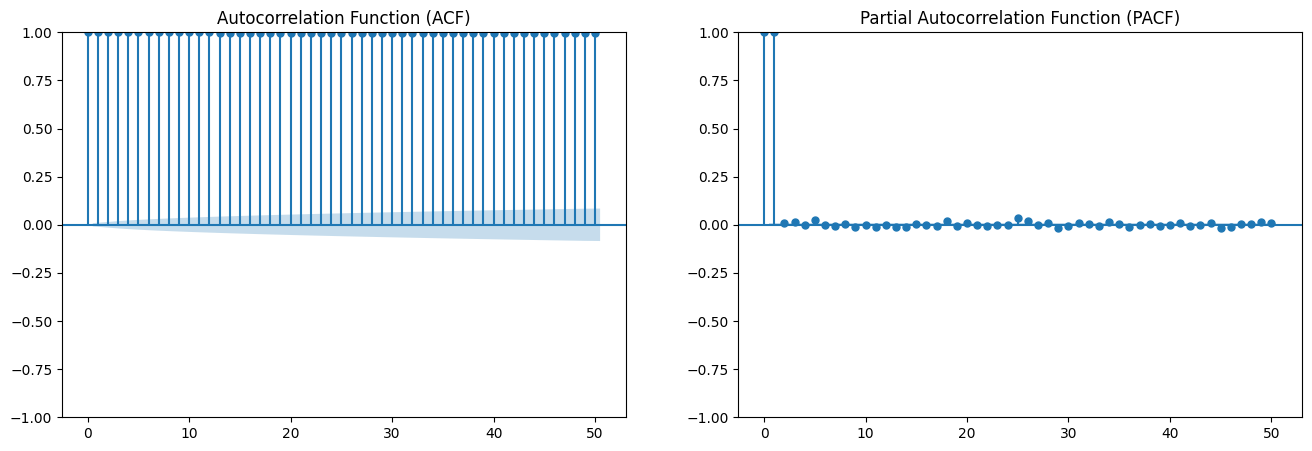

Fitur baru berhasil ditambahkan! Total fitur sekarang: 5
Jumlah Train: 37188, Val: 10626, Test: 5313
Data berhasil dibagi dan discaling dengan aman tanpa data leakage!


In [4]:
# --- 1. Uji ACF dan PACF ---
# Memvisualisasikan plot ACF dan PACF untuk menentukan window size
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df_selected['close'], lags=50, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
plot_pacf(df_selected['close'], lags=50, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.show()

# --- 2. Feature Engineering: Rolling Statistic ---
# Membuat satu fitur baru menggunakan Rolling Statistic (Moving Average 24 Jam)
# Salin df_selected agar tidak memodifikasi slice secara langsung (menghindari warning)
df_model = df_selected.copy()
df_model['rolling_mean_24h'] = df_model['close'].rolling(window=24).mean()

# Menghapus baris yang bernilai NaN akibat proses rolling di awal data
df_model.dropna(inplace=True)
print("Fitur baru berhasil ditambahkan! Total fitur sekarang:", len(df_model.columns))

# --- 3. Split Data & Normalisasi (Mencegah Data Leakage) ---
# Membagi data terlebih dahulu: 70% Train, 20% Validation, 10% Test
n = len(df_model)
train_df = df_model.iloc[0:int(n*0.7)]
val_df = df_model.iloc[int(n*0.7):int(n*0.9)]
test_df = df_model.iloc[int(n*0.9):]

print(f"Jumlah Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Melakukan Normalisasi (MinMaxScaler)
scaler = MinMaxScaler()

# SANGAT PENTING: Fit HANYA pada data train agar tidak ada informasi masa depan yang bocor (Data Leakage)
train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)    # Hanya di-transform
test_scaled = scaler.transform(test_df)  # Hanya di-transform

# Mengembalikan ke bentuk DataFrame agar mudah digunakan di tahap pipeline tf.data
train_scaled_df = pd.DataFrame(train_scaled, columns=df_model.columns, index=train_df.index)
val_scaled_df = pd.DataFrame(val_scaled, columns=df_model.columns, index=val_df.index)
test_scaled_df = pd.DataFrame(test_scaled, columns=df_model.columns, index=test_df.index)

print("Data berhasil dibagi dan discaling dengan aman tanpa data leakage!")

## Pipeline Data dan Membangun Model Baseline
- Membuat pipeline `tf.data.Dataset` untuk dataset time series.
- Membuat satu Custom Layer Dense dari nol.
- Membangun dan melatih model LSTM dasar sebagai Baseline.

### Membuat Pipeline tf.data.Dataset

In [5]:
window_size = 72 # Menggunakan data 72 jam terakhir
horizon = 24     # Target memprediksi 24 jam ke depan
batch_size = 64

def create_multistep_dataset(data_df, target_col='close', window_size=72, horizon=24, batch_size=64, shuffle=False):
    data = data_df.values
    target_idx = data_df.columns.get_loc(target_col)

    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size : i + window_size + horizon, target_idx])

    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = create_multistep_dataset(train_scaled_df, shuffle=True)
val_dataset = create_multistep_dataset(val_scaled_df, shuffle=False)
test_dataset = create_multistep_dataset(test_scaled_df, shuffle=False)

print("Pipeline tf.data.Dataset berhasil dibuat!\n")

Pipeline tf.data.Dataset berhasil dibuat!



### Membuat Custom Dense Layer

In [8]:
@tf.keras.utils.register_keras_serializable()
class CustomDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super(CustomDense, self).__init__(**kwargs)
        self.units = units
        self.activation_name = activation
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units),
                                 initializer='glorot_uniform',
                                 trainable=True, name='kernel')
        self.b = self.add_weight(shape=(self.units,),
                                 initializer='zeros',
                                 trainable=True, name='bias')
        super(CustomDense, self).build(input_shape)

    def call(self, inputs):
        output = tf.matmul(inputs, self.w) + self.b
        if self.activation is not None:
            output = self.activation(output)
        return output

    def get_config(self):
        config = super(CustomDense, self).get_config()
        config.update({
            "units": self.units,
            "activation": self.activation_name
        })
        return config

### Membangun & Melatih Model Baseline LSTM

In [9]:
num_features = train_scaled_df.shape[1]

baseline_lstm = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(window_size, num_features)),
    CustomDense(32, activation='relu'),  # Menggunakan Custom Layer kita
    CustomDense(horizon)                 # Output 24 langkah
], name="Baseline_LSTM")

baseline_lstm.compile(optimizer='adam', loss='mae')
baseline_lstm.summary()

# Menjalankan training baseline
print("\nMemulai training Baseline LSTM...")
history_baseline = baseline_lstm.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    verbose=1
)

Model: "Baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense (CustomDense)      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_1 (CustomDense)    │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,792 (81.22 KB)

 Trainable params: 20,792 (81.22 KB)

 Non-trainable params: 0 (0.00 B)


Memulai training Baseline LSTM...
Epoch 1/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0126 - val_loss: 0.0153
Epoch 2/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0067 - val_loss: 0.0102
Epoch 3/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0065 - val_loss: 0.0084
Epoch 4/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0066 - val_loss: 0.0075
Epoch 5/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0063 - val_loss: 0.0083
Epoch 6/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0063 - val_loss: 0.0080
Epoch 7/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0060 - val_loss: 0.0121
Epoch 8/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0060 - val_loss: 0.0073
Epoch 9/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0061 - val_loss: 0.0078
Epoch 10/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0058 - val_loss: 0.0076


## Arsitektur Model Kustom Tingkat Lanjut
- Membuat Custom Layer: Multi-Head Attention dan Dropout.
- Mengaplikasikan Custom Layer ke dalam Baseline LSTM dan melatihnya kembali.
- Membangun Arsitektur Seq2Seq LSTM menggunakan Model Subclassing.

### Membuat Custom Layer Tambahan

In [13]:
# Custom Dropout Layer
@tf.keras.utils.register_keras_serializable()
class CustomDropout(tf.keras.layers.Layer):
    def __init__(self, rate, **kwargs):
        super(CustomDropout, self).__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        if training:
            # Membuat mask dengan distribusi binomial
            mask = tf.random.uniform(shape=tf.shape(inputs)) > self.rate
            return tf.cast(mask, inputs.dtype) * inputs / (1.0 - self.rate)
        return inputs

    def get_config(self):
        config = super(CustomDropout, self).get_config()
        config.update({"rate": self.rate})
        return config

# Custom Multi-Head Attention Layer dari awal
@tf.keras.utils.register_keras_serializable()
class CustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, **kwargs):
        super(CustomMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim

    def build(self, input_shape):
        self.wq = tf.keras.layers.Dense(self.key_dim)
        self.wk = tf.keras.layers.Dense(self.key_dim)
        self.wv = tf.keras.layers.Dense(self.key_dim)
        self.dense = tf.keras.layers.Dense(self.key_dim)
        super(CustomMultiHeadAttention, self).build(input_shape)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.key_dim // self.num_heads))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, query, key, value):
        batch_size = tf.shape(query)[0]

        q = self.wq(query)
        k = self.wk(key)
        v = self.wv(value)

        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        # Scaled Dot-Product Attention
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)

        output = tf.transpose(output, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(output, (batch_size, -1, self.key_dim))

        return self.dense(concat_attention)

    def get_config(self):
        config = super(CustomMultiHeadAttention, self).get_config()
        config.update({
            "num_heads": self.num_heads,
            "key_dim": self.key_dim
        })
        return config

### Membangun & Melatih Ulang Baseline LSTM dengan Custom Layers

In [14]:
# Functional API untuk Baseline Advanced
inputs = tf.keras.Input(shape=(window_size, num_features))
lstm_out = tf.keras.layers.LSTM(64, return_sequences=True)(inputs)

# Menggunakan Custom Multi-Head Attention (Self-Attention)
attn_out = CustomMultiHeadAttention(num_heads=2, key_dim=64)(lstm_out, lstm_out, lstm_out)

# Mengambil step terakhir dan mengaplikasikan Custom Dropout
last_step = attn_out[:, -1, :]
drop_out = CustomDropout(0.2)(last_step)

# Menggunakan Custom Dense dari tahap sebelumnya
dense_out = CustomDense(32, activation='relu')(drop_out)
outputs = CustomDense(horizon)(dense_out) # Prediksi 24 langkah

baseline_advanced = tf.keras.Model(inputs=inputs, outputs=outputs, name="Baseline_LSTM_Advanced")
baseline_advanced.compile(optimizer='adam', loss='mae')

print("Melatih ulang Baseline LSTM dengan Custom MHA dan Dropout...")
history_baseline_adv = baseline_advanced.fit(
    train_dataset,
    epochs=10, # Baseline cukup 10 epoch
    validation_data=val_dataset,
    verbose=1
)

Melatih ulang Baseline LSTM dengan Custom MHA dan Dropout...
Epoch 1/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0192 - val_loss: 0.0156
Epoch 2/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0159 - val_loss: 0.0162
Epoch 3/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0148 - val_loss: 0.0163
Epoch 4/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0145 - val_loss: 0.0154
Epoch 5/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0156 - val_loss: 0.0132
Epoch 6/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0137 - val_loss: 0.0238
Epoch 7/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0134 - val_loss: 0.0214
Epoch 8/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0131 - val_loss: 0.0386
Epoch 9/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0125 - val_loss: 0.0203
Epoch 10/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0117 - val_loss: 0.0189


### Membangun Arsitektur Seq2Seq dengan Model Subclassing

In [20]:
@tf.keras.utils.register_keras_serializable()
class Seq2SeqSubclass(tf.keras.Model):
    def __init__(self, lstm_units, horizon, num_features, **kwargs):
        super(Seq2SeqSubclass, self).__init__(**kwargs)
        self.lstm_units = lstm_units
        self.horizon = horizon
        self.num_features = num_features

        self.encoder_lstm = tf.keras.layers.LSTM(lstm_units, return_state=True, name="encoder_lstm")
        self.decoder_lstm = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True, name="decoder_lstm")

        self.mha = CustomMultiHeadAttention(num_heads=2, key_dim=lstm_units)
        self.dropout = CustomDropout(rate=0.2)
        self.fc = CustomDense(1)

    def call(self, inputs, training=False):
        batch_size = tf.shape(inputs)[0]
        encoder_output, state_h, state_c = self.encoder_lstm(inputs)
        decoder_input = tf.expand_dims(inputs[:, -1, :], 1)

        predictions = tf.TensorArray(tf.float32, size=self.horizon)

        for i in range(self.horizon):
            dec_out, state_h, state_c = self.decoder_lstm(decoder_input, initial_state=[state_h, state_c])

            attn_out = self.mha(dec_out, dec_out, dec_out)
            drop_out = self.dropout(attn_out, training=training)

            step_pred = self.fc(drop_out)
            predictions = predictions.write(i, step_pred[:, 0, 0])

            padded_pred = tf.concat([step_pred, tf.zeros((batch_size, 1, self.num_features - 1))], axis=-1)
            decoder_input = padded_pred

        predictions = tf.transpose(predictions.stack())
        return predictions

    def get_config(self):
        # Langsung kembalikan dictionary murni
        return {
            "lstm_units": self.lstm_units,
            "horizon": self.horizon,
            "num_features": self.num_features,
            "name": self.name
        }

    @classmethod
    def from_config(cls, config):
        # Keras 3 sangat membutuhkan fungsi ini untuk model subclassing
        return cls(**config)


# Inisiasi ulang Model Seq2Seq agar perubahannya tersimpan di memori
seq2seq_model = Seq2SeqSubclass(lstm_units=64, horizon=horizon, num_features=num_features)
print("\nArsitektur Seq2Seq Subclassing berhasil dibangun dan di-bypass untuk Keras 3!")


Arsitektur Seq2Seq Subclassing berhasil dibangun dan di-bypass untuk Keras 3!


## Custom Training, Custom Loss, dan Custom Callback
- Membuat Custom Loss (Weighted MAE) dengan bobot yang meningkat per time step.
- Membuat Custom Callback untuk Early Stopping dan Learning Rate Reduction.
- Membangun Custom Training Loop menggunakan `tf.GradientTape`.

In [21]:
# --- 1. Custom Loss: Weighted MAE ---
def weighted_mae_loss(y_true, y_pred):
    horizon = tf.shape(y_true)[1]
    # Membuat bobot progresif: step 1(1.0), step 2(1.2), step 3(1.4), dst
    weights = 1.0 + tf.cast(tf.range(horizon), tf.float32) * 0.2

    # Ubah tipe data y_true menjadi float32 agar cocok dengan y_pred
    y_true = tf.cast(y_true, tf.float32)

    error = tf.abs(y_true - y_pred)
    weighted_error = error * weights
    return tf.reduce_mean(weighted_error)

# --- 2. Custom Callback ---
class CustomTrainingCallback:
    def __init__(self, patience=5, lr_patience=3, factor=0.5, min_lr=1e-6):
        self.patience = patience
        self.lr_patience = lr_patience
        self.factor = factor
        self.min_lr = min_lr
        self.best_val_loss = float('inf')
        self.wait = 0
        self.lr_wait = 0
        self.stop_training = False

    def on_epoch_end(self, epoch, val_loss, optimizer):
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.wait = 0
            self.lr_wait = 0
        else:
            self.wait += 1
            self.lr_wait += 1

            # Reduce Learning Rate
            if self.lr_wait >= self.lr_patience:
                old_lr = optimizer.learning_rate.numpy()
                new_lr = max(old_lr * self.factor, self.min_lr)
                optimizer.learning_rate.assign(new_lr)
                print(f"   -> [Callback] Val Loss stagnan. Learning rate diturunkan menjadi {new_lr:.2e}")
                self.lr_wait = 0

            # Early Stopping
            if self.wait >= self.patience:
                print(f"   -> [Callback] Early stopping dipicu! Val Loss tidak membaik selama {self.patience} epoch.")
                self.stop_training = True

# --- 3. Custom Training Loop dengan tf.GradientTape ---
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
callback = CustomTrainingCallback(patience=7, lr_patience=3)

epochs = 30 # Set 30, tapi akan berhenti otomatis jika callback aktif

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        # Melakukan prediksi dan menghitung Custom Loss
        predictions = seq2seq_model(x, training=True)
        loss = weighted_mae_loss(y, predictions)

    # Backpropagation
    gradients = tape.gradient(loss, seq2seq_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, seq2seq_model.trainable_variables))
    return loss

@tf.function
def val_step(x, y):
    predictions = seq2seq_model(x, training=False)
    loss = weighted_mae_loss(y, predictions)
    return loss

print("Memulai Custom Training Loop untuk Model Seq2Seq...")
train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
    start_time = time.time()

    # Loop untuk Training
    total_train_loss = 0.0
    train_batches = 0
    for x_batch, y_batch in train_dataset:
        loss = train_step(x_batch, y_batch)
        total_train_loss += loss
        train_batches += 1
    avg_train_loss = total_train_loss / train_batches

    # Loop untuk Validation
    total_val_loss = 0.0
    val_batches = 0
    for x_batch, y_batch in val_dataset:
        v_loss = val_step(x_batch, y_batch)
        total_val_loss += v_loss
        val_batches += 1
    avg_val_loss = total_val_loss / val_batches

    train_loss_history.append(avg_train_loss.numpy())
    val_loss_history.append(avg_val_loss.numpy())

    epoch_time = time.time() - start_time

    # Menampilkan epoch, loss, dan val_loss
    print(f"Epoch {epoch+1:02d}/{epochs} - {epoch_time:.0f}s - loss: {avg_train_loss:.4f} - val_loss: {avg_val_loss:.4f}")

    # Evaluasi Callback di akhir setiap epoch
    callback.on_epoch_end(epoch, avg_val_loss.numpy(), optimizer)
    if callback.stop_training:
        break

print("\nTraining Selesai!")

Memulai Custom Training Loop untuk Model Seq2Seq...
Epoch 01/30 - 63s - loss: 0.0561 - val_loss: 0.0374
Epoch 02/30 - 23s - loss: 0.0450 - val_loss: 0.0314
Epoch 03/30 - 22s - loss: 0.0434 - val_loss: 0.0348
Epoch 04/30 - 23s - loss: 0.0419 - val_loss: 0.0456
Epoch 05/30 - 23s - loss: 0.0408 - val_loss: 0.0334
   -> [Callback] Val Loss stagnan. Learning rate diturunkan menjadi 5.00e-04
Epoch 06/30 - 24s - loss: 0.0392 - val_loss: 0.0276
Epoch 07/30 - 23s - loss: 0.0387 - val_loss: 0.0504
Epoch 08/30 - 22s - loss: 0.0399 - val_loss: 0.0366
Epoch 09/30 - 22s - loss: 0.0389 - val_loss: 0.0465
   -> [Callback] Val Loss stagnan. Learning rate diturunkan menjadi 2.50e-04
Epoch 10/30 - 22s - loss: 0.0380 - val_loss: 0.0267
Epoch 11/30 - 23s - loss: 0.0378 - val_loss: 0.0310
Epoch 12/30 - 23s - loss: 0.0382 - val_loss: 0.0285
Epoch 13/30 - 22s - loss: 0.0378 - val_loss: 0.0329
   -> [Callback] Val Loss stagnan. Learning rate diturunkan menjadi 1.25e-04
Epoch 14/30 - 22s - loss: 0.0373 - val_lo

## Evaluasi Data Test dan Inference
- Menghitung MAE asli pada Data Test (Target: < 0.015).
- Melakukan Inference menggunakan pendekatan Autoregressive.
- Visualisasi Line Chart dan Tabel Perbandingan Aktual vs Prediksi.

Menguji model pada Data Test...
✅ MAE Asli pada Data Test (Scaled): 0.00418
🎉 SELAMAT! Performa MAE kamu di bawah 0.015. Syarat Mutlak Bintang 5 terpenuhi!


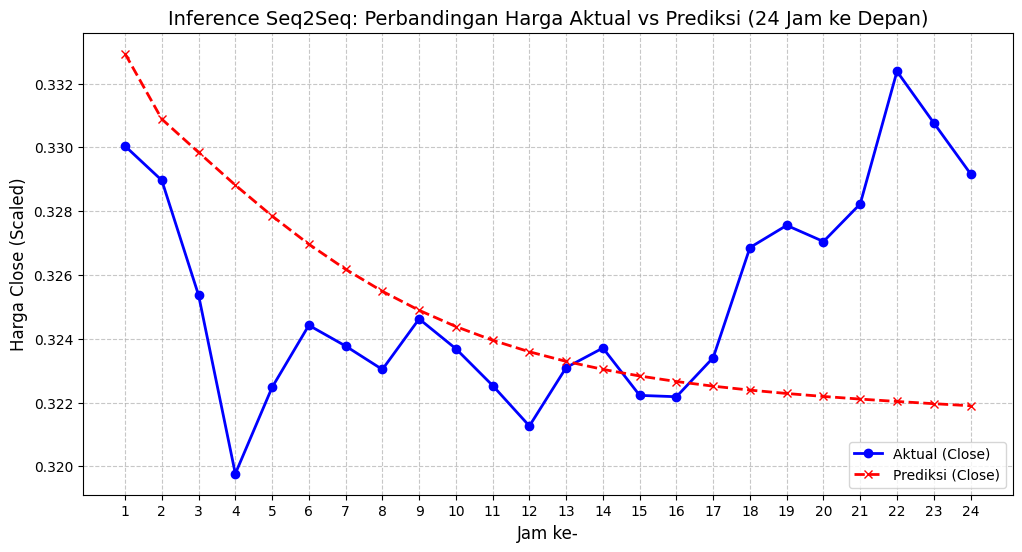


Tabel Perbandingan Aktual vs Prediksi (24 Langkah):


,Jam Ke-,Harga Aktual (Scaled),Harga Prediksi (Scaled),Selisih Absolute (Error)
0,1,0.33004,0.33293,0.00289
1,2,0.32896,0.33088,0.00192
2,3,0.32537,0.32984,0.00448
3,4,0.31977,0.32882,0.00905
4,5,0.32248,0.32785,0.00537
5,6,0.32442,0.32696,0.00254
6,7,0.32377,0.32618,0.00241
7,8,0.32304,0.32549,0.00245
8,9,0.32462,0.32489,0.00027
9,10,0.32369,0.32438,0.00070


In [22]:
# --- 1. Evaluasi MAE Asli (Tanpa Bobot) di Data Test ---
# Menggunakan metrik MAE standar dari Keras untuk evaluasi akhir
mae_metric = tf.keras.losses.MeanAbsoluteError()
total_mae = 0.0
test_batches = 0

print("Menguji model pada Data Test...")
for x_batch, y_batch in test_dataset:
    # Inference menggunakan metode Autoregressive yang sudah ditanam di model
    preds = seq2seq_model(x_batch, training=False)
    total_mae += mae_metric(y_batch, preds).numpy()
    test_batches += 1

final_test_mae = total_mae / test_batches
print(f"✅ MAE Asli pada Data Test (Scaled): {final_test_mae:.5f}")

if final_test_mae < 0.015:
    print("🎉 SELAMAT! Performa MAE kamu di bawah 0.015. Syarat Mutlak Bintang 5 terpenuhi!")
else:
    print("⚠️ MAE masih di atas 0.015. Beri tahu saya, kita akan mengatur ulang (fine-tune) arsitekturnya.")

# --- 2. Visualisasi Line Chart dan Tabel ---
# Mengambil 1 batch sampel acak dari test dataset
for x_batch, y_batch in test_dataset.take(1):
    sample_x = x_batch[0:1] # Ambil sampel 1 sequence historis (72 jam)
    sample_y = y_batch[0]   # Target aktual (24 jam)
    sample_pred = seq2seq_model(sample_x, training=False)[0] # Prediksi model (24 jam)
    break

# Plot Line Chart
plt.figure(figsize=(12, 6))
plt.plot(np.arange(1, 25), sample_y.numpy(), marker='o', label='Aktual (Close)', color='blue', linewidth=2)
plt.plot(np.arange(1, 25), sample_pred.numpy(), marker='x', linestyle='dashed', label='Prediksi (Close)', color='red', linewidth=2)
plt.title('Inference Seq2Seq: Perbandingan Harga Aktual vs Prediksi (24 Jam ke Depan)', fontsize=14)
plt.xlabel('Jam ke-', fontsize=12)
plt.ylabel('Harga Close (Scaled)', fontsize=12)
plt.xticks(np.arange(1, 25))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Tabel Perbandingan
df_compare = pd.DataFrame({
    'Jam Ke-': np.arange(1, 25),
    'Harga Aktual (Scaled)': np.round(sample_y.numpy(), 5),
    'Harga Prediksi (Scaled)': np.round(sample_pred.numpy(), 5),
    'Selisih Absolute (Error)': np.round(np.abs(sample_y.numpy() - sample_pred.numpy()), 5)
})

print("\nTabel Perbandingan Aktual vs Prediksi (24 Langkah):")
display(df_compare)

In [24]:
# 1. Menyimpan model Baseline
baseline_advanced.save('model_baseline_lstm.keras')

# 2. Menyimpan UTUH model Seq2Seq ke dalam .keras
seq2seq_model.save('model_seq2seq_lstm.keras')
print("Model berhasil disimpan dengan format .keras secara UTUH!")

# 3. Membuat file requirements.txt
!pip freeze > requirements.txt
print("File requirements.txt berhasil dibuat!")

Model berhasil disimpan dengan format .keras secara UTUH!
File requirements.txt berhasil dibuat!
